# WORK IN PROGRESS

# Final Project

#### Title: Machine Learning for Obesity Level Prediction and Lifesytle Pattern Discovery
#### Class: AAI 501-02 - Introduction to Artificial Intelligence
#### Team 4: Dina Othman, Erika Gallegos, Hassaan Abbasi

In [2]:
pip install ucimlrepo

In [46]:
## libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

## Data

In [5]:
from ucimlrepo import fetch_ucirepo

## get data
df = fetch_ucirepo(id = 544)

## Supervised Machine Learning

### Logistic Regression

Predicting obesity level (NObeyesdad).

Values:  
Obesity_Type_I  
Obesity_Type_III  
Obesity_Type_II  
Overweight_Level_I  
Overweight_Level_II  
Normal_Weight  
Insufficient_Weight  

In [9]:
## format data
x = df.data.features
y = df.data.targets

In [24]:
## identify column types
categorical_cols = x.select_dtypes(include = ['object', 'category']).columns.tolist()
numeric_cols = x.select_dtypes(include = ['int64', 'float64']).columns.tolist()

In [23]:
## split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 33, stratify = y)

In [26]:
## scale numerical variables, dummy level categoricals

# training data
ohe = OneHotEncoder(drop = 'first', sparse_output = False)
x_train_cat = ohe.fit_transform(x_train[categorical_cols])
x_test_cat = ohe.transform(x_test[categorical_cols])

# test data
scaler = StandardScaler()
x_train_num = scaler.fit_transform(x_train[numeric_cols])
x_test_num = scaler.transform(x_test[numeric_cols])

In [27]:
## recombine transformed variables

# training data
x_train_processed = np.hstack([x_train_num, x_train_cat])

# test data
x_test_processed = np.hstack([x_test_num, x_test_cat])

In [28]:
## train model
model = LogisticRegression()
model.fit(x_train_processed, y_train)

LogisticRegression()

In [34]:
## evaluate model performance on test data
y_pred = model.predict(x_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names = df.target_names))

Accuracy: 0.8817966903073287

Confusion Matrix:
 [[52  2  0  0  0  0  0]
 [10 43  0  0  0  3  2]
 [ 0  0 61  3  1  0  5]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 65  0  0]
 [ 0  5  0  0  0 45  8]
 [ 0  0  4  0  0  7 47]]

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.84      0.96      0.90        54
      Normal_Weight       0.86      0.74      0.80        58
     Obesity_Type_I       0.94      0.87      0.90        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.82      0.78      0.80        58
Overweight_Level_II       0.76      0.81      0.78        58

           accuracy                           0.88       423
          macro avg       0.88      0.88      0.88       423
       weighted avg       0.88      0.88      0.88       423



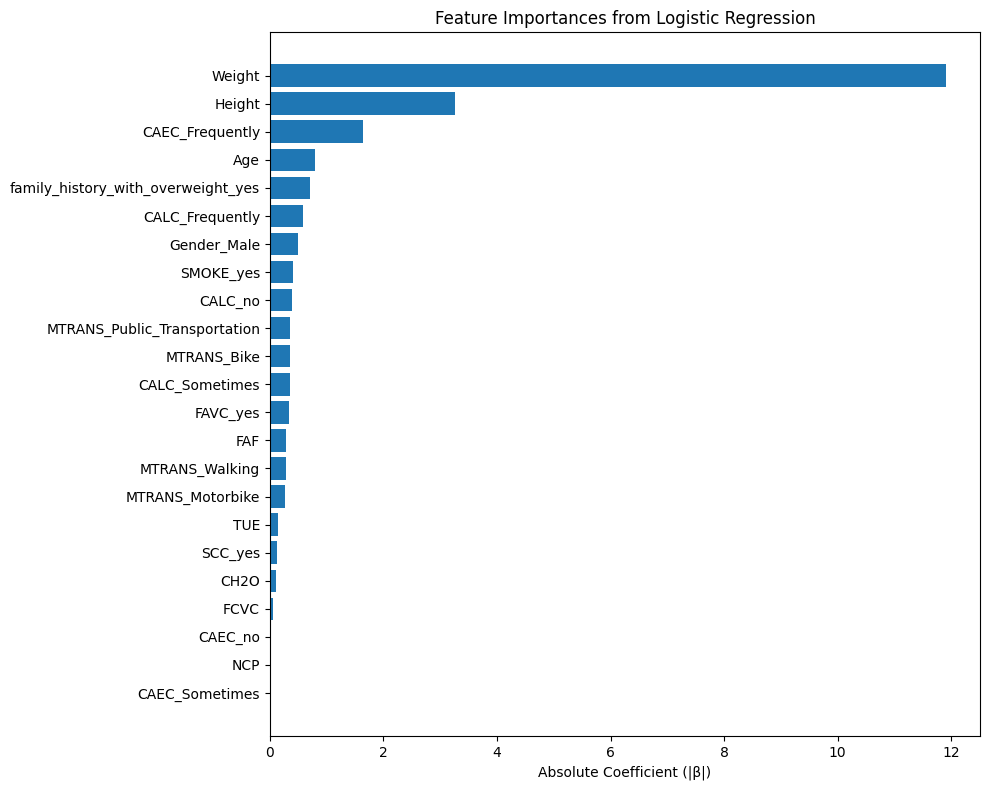

In [39]:
## plot feature importance

# get categorical feature names
encoded_cat_names = ohe.get_feature_names_out(categorical_cols)

# get numeric feature names and append categorical
all_feature_names = numeric_cols + list(encoded_cat_names)

# logistic regression coefficients
coefs = model.coef_[0]

# get feature importance values
feature_importances = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefs,
    'importance': np.abs(coefs)
}).sort_values('importance', ascending = False)

feature_importances.head()

# create plot
plt.figure(figsize = (6, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Absolute Coefficient (|β|)')
plt.title('Feature Importances from Logistic Regression')
plt.gca().invert_yaxis()  # largest at top
plt.tight_layout()
plt.show()

### Random Forest

In [42]:
## base model
rf = RandomForestClassifier(
    n_estimators = 500,
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 1,
    random_state = 33,
    n_jobs = -1
)

## train model
rf.fit(x_train_processed, y_train)


RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [43]:
## evaluate model performance
y_pred_rf = rf.predict(x_test_processed)

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9527186761229315

Confusion Matrix:
 [[50  4  0  0  0  0  0]
 [ 1 56  0  0  0  1  0]
 [ 0  0 69  1  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 65  0  0]
 [ 0  8  0  0  0 49  1]
 [ 0  4  0  0  0  0 54]]

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.98      0.93      0.95        54
      Normal_Weight       0.78      0.97      0.86        58
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.98      0.84      0.91        58
Overweight_Level_II       0.98      0.93      0.96        58

           accuracy                           0.95       423
          macro avg       0.96      0.95      0.95       423
       weighted avg       0.96      0.95      0.95       423



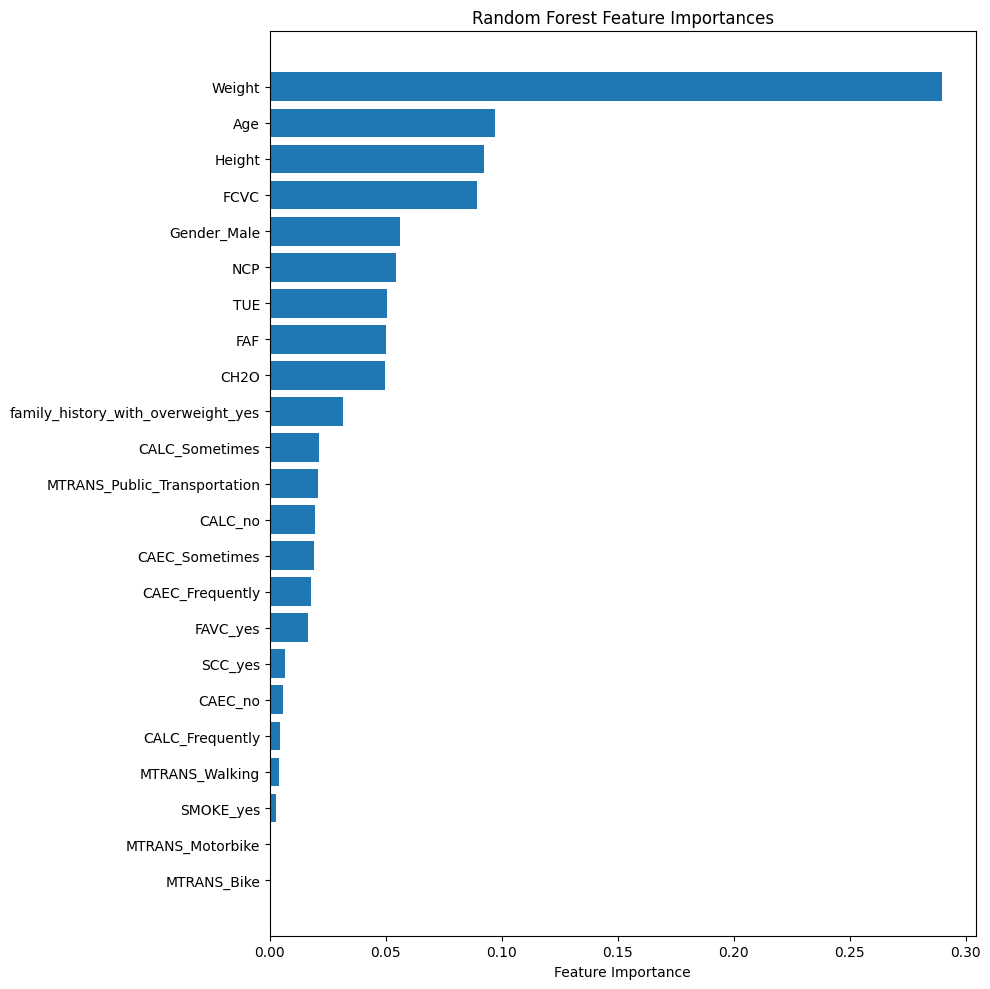

In [45]:
## create feature importance plot

importances = rf.feature_importances_

rf_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending = False)

# plot
plt.figure(figsize=(6, 6))
plt.barh(rf_imp['feature'], rf_imp['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
## tune model
rf = RandomForestClassifier(random_state = 42)

param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": [10, 20, 30, None],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,                # try 40 combinations
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(x_train_processed, y_train)

print("Best Score from Randomized Search:", random_search.best_score_)
print("Best Params from Randomized Search:\n", random_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


KeyboardInterrupt: 

In [ ]:
## evaluate model performance

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(x_test_processed)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
# Get feature importances from the best model
importances = best_rf.feature_importances_

# Build a dataframe
rf_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Plot all importances
plt.figure(figsize=(10, 12))
plt.barh(rf_imp["feature"], rf_imp["importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (Tuned RF)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
